In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import scipy.stats
from scipy.stats import beta as beta_dist

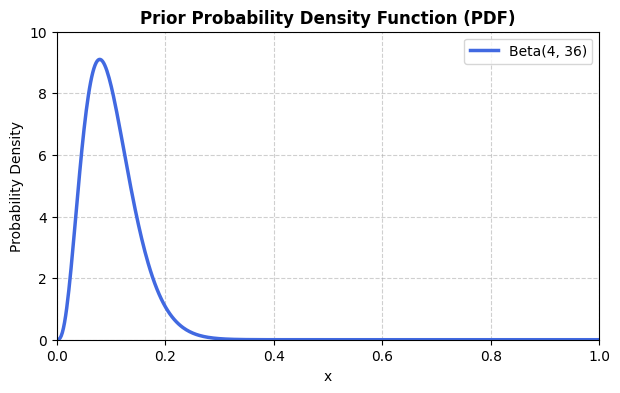

In [ ]:
a = 4
b = 36

x = np.linspace(0, 1, 500)

y = beta.pdf(x, a, b)

plt.figure(figsize=(7, 4))
plt.plot(x, y, label=f'Beta({a}, {b})', color='royalblue', lw=2.5)


plt.title('Prior Probability Density Function (PDF)', fontsize=12, fontweight='bold')
plt.xlabel('x', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 1)
plt.ylim(0, 10)
plt.legend()

plt.show()


# Email conversion rate example

In [ ]:
alpha_prior, beta_prior = 4, 36
n, x = 150, 23

# Known closed-form posterior (conjugacy) -- our ground truth
alpha_post_true = alpha_prior + x
beta_post_true = beta_prior + n - x
prior = beta_dist(alpha_prior, beta_prior)
observed_rate = x / n
true_posterior = beta_dist(alpha_post_true, beta_post_true)

print(f"True analytical posterior: Beta({alpha_post_true}, {beta_post_true})")
print(f"True posterior mean: {true_posterior.mean():.4f}")

map_estimate = (alpha_post_true - 1) / (alpha_post_true + beta_post_true - 2)
print(f"True posterior MAP: {map_estimate:.4f}")

True analytical posterior: Beta(27, 163)
True posterior mean: 0.1421
True posterior MAP: 0.1383


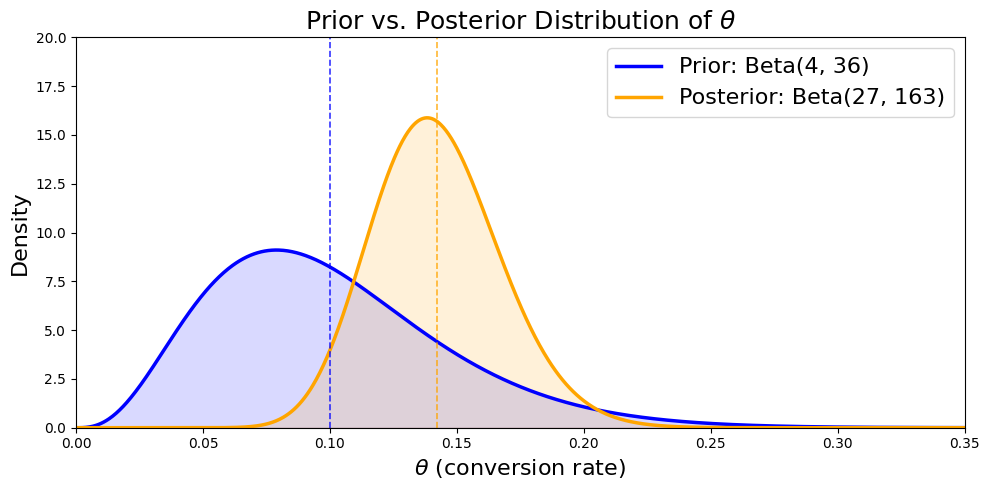

In [ ]:
theta_grid = np.linspace(0, 0.35, 1000)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(theta_grid, prior.pdf(theta_grid), color="blue", linewidth=2.5,
        label=fr"Prior: Beta({alpha_prior}, {beta_prior})")
ax.fill_between(theta_grid, prior.pdf(theta_grid), color="blue", alpha=0.15)

ax.plot(theta_grid, true_posterior.pdf(theta_grid), color="orange", linewidth=2.5,
        label=fr"Posterior: Beta({alpha_post_true}, {beta_post_true})")
ax.fill_between(theta_grid, true_posterior.pdf(theta_grid), color="orange", alpha=0.15)

ax.axvline(prior.mean(), color="blue", linestyle="--", linewidth=1.2, alpha=0.8)
ax.axvline(true_posterior.mean(), color="orange", linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_xlabel(r"$\theta$ (conversion rate)", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
ax.set_title("Prior vs. Posterior Distribution of $\\theta$", fontsize=18)
ax.legend(fontsize=16)
ax.set_xlim(0, 0.35)
ax.set_ylim(0, 20)

plt.tight_layout()

In [ ]:
with pm.Model() as conversion_model:
    theta = pm.Beta("theta", alpha=alpha_prior, beta=beta_prior)
    pm.Binomial("x_obs", n=n, p=theta, observed=x)

In [ ]:
with conversion_model:
    trace = pm.sample(2000, tune=1000)

ci = az.hdi(trace, hdi_prob=0.95)["theta"].values

print(ci)

Output()

[0.09321341 0.19022877]


In [ ]:
pm.find_MAP(model=conversion_model)

Output()

{'theta_logodds__': array(-1.82949982), 'theta': array(0.13829787)}

In [ ]:
# Rerun the sampler multiple times with different seeds
n_reruns = 5
draws = 1000
tune = 1000
chains = 2

posterior_samples = []
posterior_means = []

for run_idx in range(n_reruns):
    with conversion_model:
        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            random_seed=1000 + run_idx,
            progressbar=False,
            compute_convergence_checks=False,
            cores=1,
        )
    samples = idata.posterior["theta"].values.flatten()
    posterior_samples.append(samples)
    posterior_means.append(samples.mean())
    print(f"Run {run_idx + 1}: posterior mean = {samples.mean():.4f}, "
          f"sd = {samples.std():.4f}")

posterior_means = np.array(posterior_means)
print("\nAcross reruns:")
print(f"  Mean of posterior means: {posterior_means.mean():.4f}")
print(f"  Std of posterior means:  {posterior_means.std():.5f}")
print(f"  True posterior mean:     {true_posterior.mean():.4f}")

Run 1: posterior mean = 0.1426, sd = 0.0257
Run 2: posterior mean = 0.1421, sd = 0.0255
Run 3: posterior mean = 0.1412, sd = 0.0249
Run 4: posterior mean = 0.1401, sd = 0.0258
Run 5: posterior mean = 0.1434, sd = 0.0259

Across reruns:
  Mean of posterior means: 0.1419
  Std of posterior means:  0.00113
  True posterior mean:     0.1421


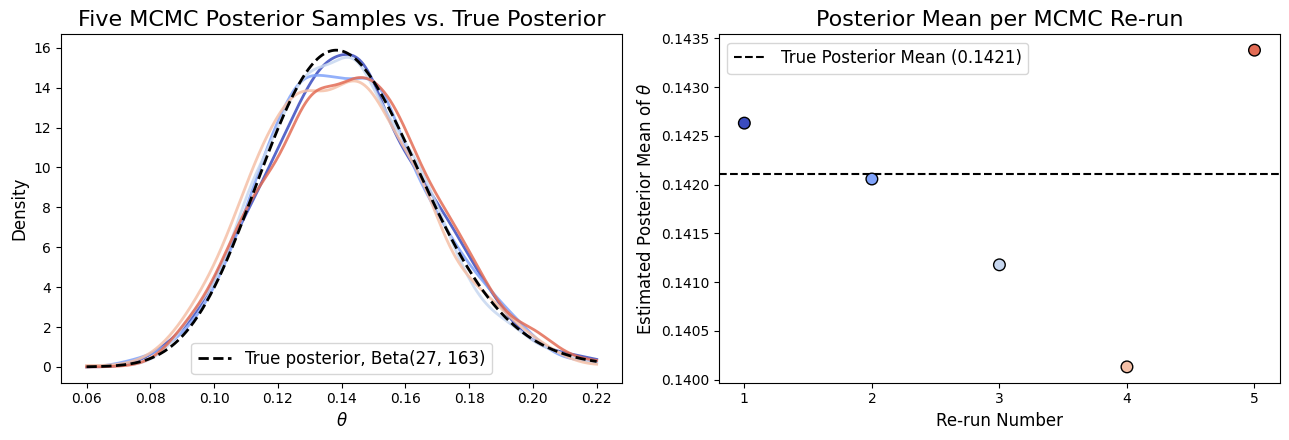

In [ ]:
# PLOT
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

theta_grid = np.linspace(0.06, 0.22, 500)
ax = axes[0]

colors = plt.cm.coolwarm(np.linspace(0, 0.85, n_reruns))
for i, samples in enumerate(posterior_samples):
    kde = gaussian_kde(samples)
    ax.plot(theta_grid, kde(theta_grid), color=colors[i], alpha=0.85,
            linewidth=2)

ax.plot(theta_grid, true_posterior.pdf(theta_grid),
        color="black", linewidth=2, linestyle="--",
        label="True posterior, Beta(27, 163)")
ax.set_xlabel(r"$\theta$", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Five MCMC Posterior Samples vs. True Posterior", fontsize=16)
ax.legend(fontsize=12)

ax = axes[1]
ax.scatter(range(1, n_reruns + 1), posterior_means, color=colors, s=70,
           zorder=3, edgecolor="black")
ax.axhline(true_posterior.mean(), color="black", linestyle="--",
           linewidth=1.5, label="True Posterior Mean (0.1421)")
ax.set_xlabel("Re-run Number", fontsize=12)
ax.set_ylabel(r"Estimated Posterior Mean of $\theta$", fontsize=12)
ax.set_title("Posterior Mean per MCMC Re-run", fontsize=16)
ax.set_xticks(range(1, n_reruns + 1))
ax.legend(fontsize=12)

plt.tight_layout()

## Examining prior informativeness

Flat Prior: Beta(1, 1), mean = 0.500, pseudo-observations (alpha+beta) = 2
Jeffreys Prior: Beta(0.5, 0.5), mean = 0.500, pseudo-observations (alpha+beta) = 1.0
Weakly Informative Prior: Beta(4, 36), mean = 0.100, pseudo-observations (alpha+beta) = 40
Strongly Informative Prior: Beta(20, 180), mean = 0.100, pseudo-observations (alpha+beta) = 200


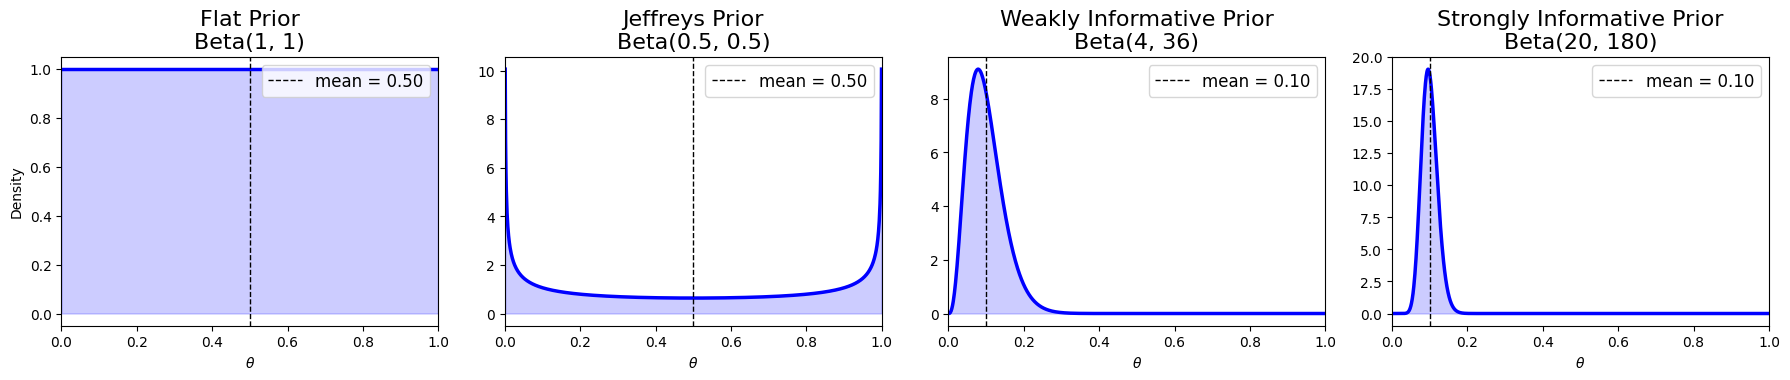

In [ ]:
priors = [
    ("Flat Prior", 1, 1),
    ("Jeffreys Prior", 0.5, 0.5),
    ("Weakly Informative Prior", 4, 36),
    ("Strongly Informative Prior", 20, 180),
]

theta_grid = np.linspace(0.001, 0.999, 1000)

# PLOT
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=False)

for ax, (name, a, b) in zip(axes, priors):
    dist = beta_dist(a, b)
    pdf = dist.pdf(theta_grid)

    ax.plot(theta_grid, pdf, color="blue", linewidth=2.5)
    ax.fill_between(theta_grid, pdf, color="blue", alpha=0.2)
    ax.axvline(dist.mean(), color="black", linestyle="--", linewidth=1,
               label=f"mean = {dist.mean():.2f}")

    ax.set_title(f"{name}\nBeta({a}, {b})", fontsize=16)
    ax.set_xlabel(r"$\theta$")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=12, loc="upper right")

    if ax is axes[0]:
        ax.set_ylabel("Density")

    print(f"{name}: Beta({a}, {b}), mean = {dist.mean():.3f}, "
          f"pseudo-observations (alpha+beta) = {a + b}")

plt.tight_layout(rect=[0, 0, 1, 0.93])

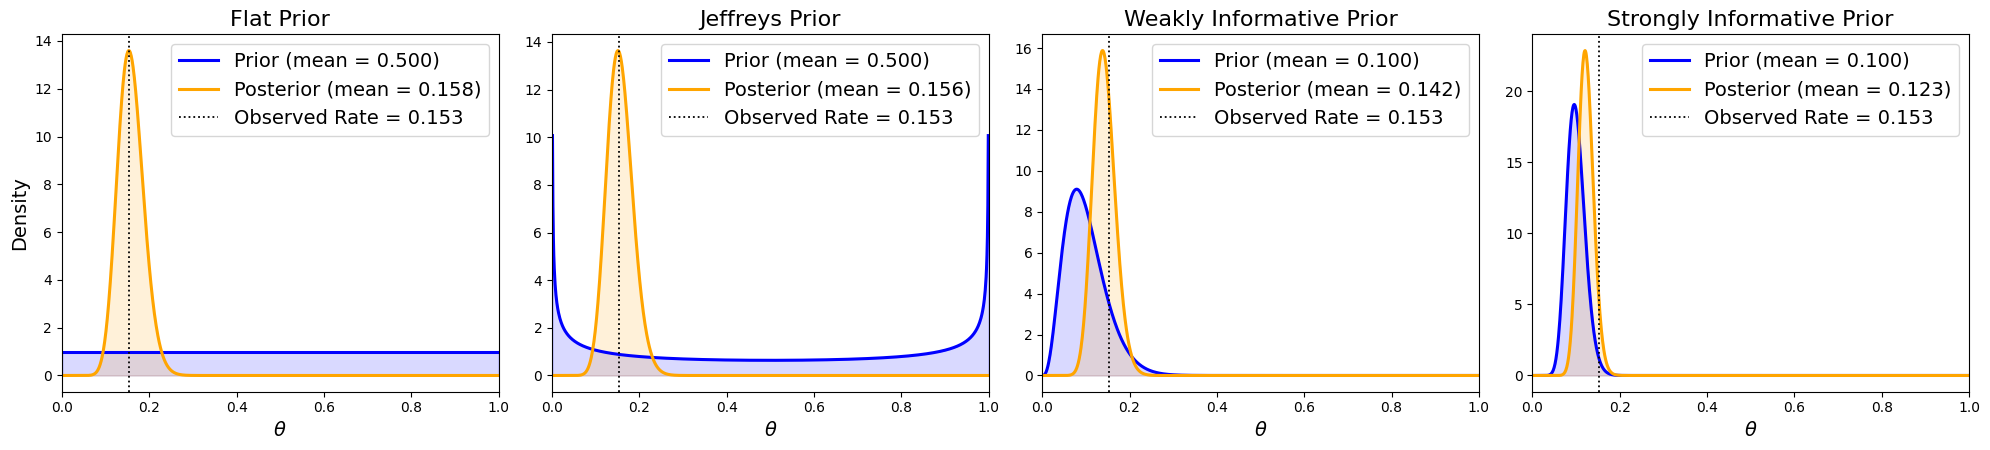

In [ ]:
n, x = 150, 23
observed_rate = x / n


theta_grid = np.linspace(0.001, 0.999, 1000)

fig, axes = plt.subplots(1, 4, figsize=(20,5), sharey=False)
axes = axes.flatten()

for ax, (name, a, b) in zip(axes, priors):
    prior = beta_dist(a, b)
    a_post, b_post = a + x, b + n - x
    posterior = beta_dist(a_post, b_post)

    prior_pdf = prior.pdf(theta_grid)
    post_pdf = posterior.pdf(theta_grid)

    ax.plot(theta_grid, prior_pdf, color="blue", linewidth=2.2,
            label=f"Prior (mean = {prior.mean():.3f})")
    ax.fill_between(theta_grid, prior_pdf, color="blue", alpha=0.15)

    ax.plot(theta_grid, post_pdf, color="orange", linewidth=2.2,
            label=f"Posterior (mean = {posterior.mean():.3f})")
    ax.fill_between(theta_grid, post_pdf, color="orange", alpha=0.15)

    ax.axvline(observed_rate, color="black", linestyle=":", linewidth=1.3,
                label=f"Observed Rate = {observed_rate:.3f}")

    ax.set_title(f"{name}", fontsize=16)
    ax.set_xlabel(r"$\theta$", fontsize=14)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=14, loc="upper right")

    if ax is axes[0]:
        ax.set_ylabel("Density", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.92])

## MAP and Credible Intervals

In [ ]:
print(beta_dist.ppf(0.025, 27, 163))
print(beta_dist.ppf(0.975, 27, 163))


0.09630192364324835
0.19503543589805591
